# CO2-Booster-Studie: MD-Expander Machbarkeitsanalyse
**Ecalia GmbH — intern — März 2026**

Vorbereitet für die Präsentation bei Kälte Fischer (Kontakt: Benaja Lötzsch).

**Fragestellung:**  
Welchen COP-Gewinn bringt ein Scroll-Expander am MD-Ventil eines CO2-Flashgas-Boosterkompressors,
verglichen mit dem Parallelverdichter als Referenz? Welche Auslegungsparameter sind
entscheidend, und wie stellt sich das Bild über alle vier Betriebsmodi des Jahres dar?

**Modell:** TESPy-Simulationsmodell mit CoolProp (CO2), kalibriert gegen BITZER-Referenzdaten.  
**Referenz:** Kälte Fischer — BITZER Software v7.1.2, 26.02.2026 (Benaja Lötzsch).

In [55]:
# =============================================================================
# 0. Setup, Imports, Globale Parameter
# =============================================================================
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from copy import deepcopy
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from CoolProp.CoolProp import PropsSI as PSI

warnings.filterwarnings("ignore")
os.makedirs("output", exist_ok=True)
matplotlib.rcParams.update({"figure.dpi": 120, "font.size": 11})

# Reload source modules after each edit
sys.path.insert(0, os.path.abspath("."))
import src.co2_booster, src.operating_points, src.plotting
for mod in [src.co2_booster, src.operating_points, src.plotting]:
    importlib.reload(mod)

from src.co2_booster import CO2BoosterFlashgasIWT, CO2BoosterParallel
from src.operating_points import (
    OP_SUMMER_NO_PV, OP_SUMMER_WITH_PV,
    OP_TRANSITION_NO_PV, OP_TRANSITION_WITH_PV,
    OP_WINTER,
    OP_WRG_NO_PV, OP_WRG_WITH_PV,
)
from src.plotting import ECALIA_BLUE, ECALIA_TEAL, ECALIA_RED, ECALIA_ORANGE

# --- Global assumptions ---
ETA_EXP        = 0.70   # Conservative scroll expander isentropic efficiency
ELECTRICITY_PRICE = 0.22  # EUR/kWh (industrial tariff)

# Seasonal operating hours per year (Lötzsch email + industry practice)
HOURS_PER_YEAR = {
    "Hochsommer":   800,
    "Übergangszeit": 3960,
    "Winter":       2000,
    "WRG-Modus":    2000,
}

# BITZER reference points indexed by OP name
BASELINE_OPS = [OP_SUMMER_NO_PV, OP_TRANSITION_NO_PV, OP_WINTER, OP_WRG_NO_PV]
PV_OPS       = [OP_SUMMER_WITH_PV, OP_TRANSITION_WITH_PV, None, OP_WRG_WITH_PV]
OP_LABELS    = ["Hochsommer", "Übergangszeit", "Winter", "WRG-Modus"]

# Helper: run a model and return (cop, W_net_kW, model | None)
def run_model(cls, op, eta_s=0.685, eta_exp=0.70, hp="valve", fg="valve",
              iwt_pos="after_exp"):
    try:
        kw = dict(compressor_efficiency=eta_s, expander_efficiency=eta_exp,
                  expansion_device_hp=hp, expansion_device_fg=fg)
        if cls is CO2BoosterFlashgasIWT:
            kw["iwt_position"] = iwt_pos
        m = cls(**kw)
        m.setup_network(iterinfo=False)
        m.set_boundary_conditions(op)
        m.solve()
        if m.converged:
            cop = m.calculate_cop_cooling()
            W   = sum(d["P_kW"] for d in m.get_power_breakdown().values())
            return cop, W, m
    except Exception:
        pass
    return float("nan"), float("nan"), None

print("Setup complete. TESPy & CoolProp ready.")

Setup complete. TESPy & CoolProp ready.


## 1. Betriebspunkte & BITZER-Referenzdaten

Kälte Fischer (Lötzsch, 26.02.2026) hat sechs typische Betriebspunkte einer
NK-only Boosteranlage (~98 kW Kälteleistung, Rewe/Edeka-Größe) berechnet.
Die TK-Stufe wurde bewusst weggelassen, damit der COP der NK-Stufe isoliert vergleichbar ist.

**BITZER-Einstellungen (konsistent über alle OPs):**
- Verdampfung: −10 °C, Überhitzung Verdampfer 6 K, Saugleitung 4 K
- Mitteldruck: 38 bar (TK-Constraint), außer PV-Varianten (43 bar)
- IWT Flashgas–Gaskühler: aktiv (Standard in BITZER Flashgas-System)

In [56]:
# =============================================================================
# 1. Betriebspunkte-Tabelle
# =============================================================================
rows = []
for op in [OP_SUMMER_NO_PV, OP_SUMMER_WITH_PV,
           OP_TRANSITION_NO_PV, OP_TRANSITION_WITH_PV,
           OP_WINTER, OP_WRG_NO_PV, OP_WRG_WITH_PV]:
    p_high_str = f"{op.p_high}" if op.p_high else \
                 f"p_sat({op.T_cond}°C)={PSI('P','Q',0,'T',273.15+op.T_cond,'CO2')/1e5:.1f}"
    rows.append({
        "Bezeichnung": op.name,
        "Betrieb": "transkrit." if op.mode == "transcritical" else "subkrit.",
        "p_high [bar]": p_high_str,
        "T_gc/T_cond [°C]": op.T_gc_out if op.T_gc_out else op.T_cond,
        "p_med [bar]": op.p_medium,
        "Q₀_NK [kW]": op.Q0_NK,
        "W_comp [kW]": op.P_total,
        "m_fg [kg/h]": op.m_flashgas,
        "COP BITZER": op.cop_bitzer,
    })

df_ops = pd.DataFrame(rows)
print(df_ops.to_string(index=False))

                                  Bezeichnung    Betrieb       p_high [bar]  T_gc/T_cond [°C]  p_med [bar]  Q₀_NK [kW]  W_comp [kW]  m_fg [kg/h]  COP BITZER
         Hochsommer (ohne Parallelverdichter) transkrit.               93.7              38.0         38.0        98.7         63.1       1130.0        1.56
          Hochsommer (mit Parallelverdichter) transkrit.               93.7              38.0         43.0        98.2         53.1       1101.0        1.85
Übergangsjahreszeit (ohne Parallelverdichter)   subkrit. p_sat(27.0°C)=67.4              27.0         38.0        98.6         33.2        480.0        2.97
 Übergangsjahreszeit (mit Parallelverdichter)   subkrit. p_sat(27.0°C)=67.4              27.0         43.0        98.6         28.8        187.0        3.43
                                Winterbetrieb   subkrit. p_sat(17.0°C)=53.4              17.0         38.0        98.9         21.8        196.1        4.54
          WRG-Modul (ohne Parallelverdichter) transkrit.  

## 2. Modellkalibrierung: η_s per Betriebspunkt

Das TESPy-Modell verwendet eine isentrope Kompressoreffizienz η_s, während BITZER
reale Verdichter-Kennfelder einsetzt. Um faire Vergleiche zu erzielen, wird η_s
für jeden der vier Basisbetriebspunkte (ohne PV) so bestimmt, dass das
Simulationsmodell mit IWT (CO2BoosterFlashgasIWT) den jeweiligen BITZER-COP exakt
reproduziert:

$$\eta_s^* = \arg\min_{\eta_s} \left| \text{COP}_\text{Sim}(\eta_s, \text{OP}) - \text{COP}_\text{BITZER}(\text{OP}) \right|$$

Die kalibrierten Werte werden anschließend auf **Plausibilität** geprüft: η_s sollte
im Bereich ~0,62–0,73 liegen (typisch für CO2-Scrollverdichter im Flashgas-Betrieb).

Betriebspunkt               COP_BITZER   η_s cal.    OK?
-----------------------------------------------------------------
  Hochsommer                      1.560      0.6909  ✓ Δ=+0.00%
  Übergangszeit                   2.970      0.6838  ✓ Δ=+0.00%
  Winter                          4.540      0.6549  ✓ Δ=+0.00%
  WRG-Modus                       2.360      0.6794  ✓ Δ=+0.00%

Kalibrierte η_s-Werte: {'Hochsommer': 0.6908909611087956, 'Übergangszeit': 0.6837964360719537, 'Winter': 0.6548994836553962, 'WRG-Modus': 0.6794374951802536}

Plausibilitätsprüfung: Erwartet ~0.62–0.73 (CO2-Scrollverdichter Flashgas-Betrieb)


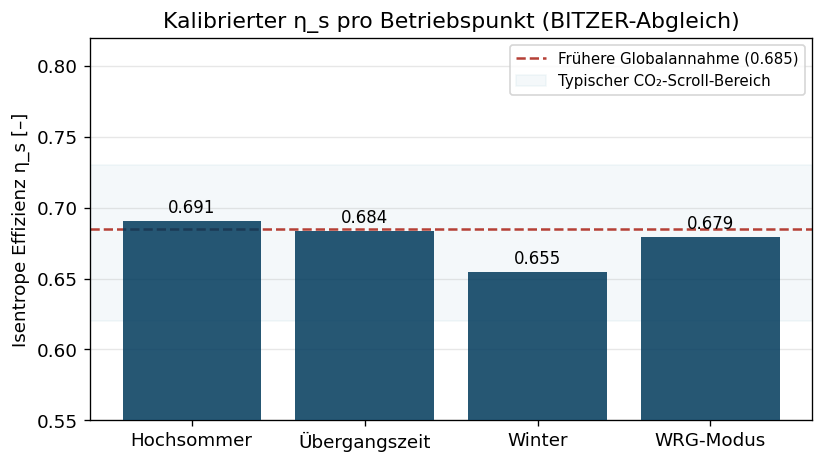

✓ Saved: output/eta_s_calibration.png


In [57]:
# =============================================================================
# 2. Kalibrierung η_s pro Betriebspunkt (Baseline = CO2BoosterFlashgasIWT)
# =============================================================================
from scipy.optimize import brentq

ETA_SEARCH_RANGE = (0.50, 0.82)  # Realistic bounds for scroll compressor

def calibrate_eta_s(op):
    # Returns eta_s that makes COP_model == COP_bitzer for a baseline IWT model.
    def residual(eta):
        cop, _, _ = run_model(CO2BoosterFlashgasIWT, op, eta_s=eta)
        return cop - op.cop_bitzer
    try:
        # bracket: at eta=0.5 COP should be below bitzer, at 0.85 above
        lo_val = residual(ETA_SEARCH_RANGE[0])
        hi_val = residual(ETA_SEARCH_RANGE[1])
        if lo_val > 0:
            return ETA_SEARCH_RANGE[0], False  # already below range
        if hi_val < 0:
            return ETA_SEARCH_RANGE[1], False  # above range
        eta_opt = brentq(residual, ETA_SEARCH_RANGE[0], ETA_SEARCH_RANGE[1], xtol=1e-4)
        return eta_opt, True
    except Exception as e:
        return 0.685, False  # fallback

ETA_S_CAL = {}  # {label: eta_s}

print("="*65)
print(f"{'Betriebspunkt':25s} {'COP_BITZER':>12s} {'η_s cal.':>10s} {'OK?':>6s}")
print("-"*65)

for label, op in zip(OP_LABELS, BASELINE_OPS):
    eta_opt, ok = calibrate_eta_s(op)
    ETA_S_CAL[label] = eta_opt
    # Verify
    cop_check, _, _ = run_model(CO2BoosterFlashgasIWT, op, eta_s=eta_opt)
    delta = abs(cop_check - op.cop_bitzer) / op.cop_bitzer * 100
    print(f"  {label:23s}  {op.cop_bitzer:12.3f}  {eta_opt:10.4f}  "
          f"{'✓' if ok and delta < 0.5 else '⚠'} Δ={delta:+.2f}%")

print("="*65)
print(f"\nKalibrierte η_s-Werte: {ETA_S_CAL}")
print("\nPlausibilitätsprüfung: Erwartet ~0.62–0.73 (CO2-Scrollverdichter Flashgas-Betrieb)")

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 4))
labels_plot = list(ETA_S_CAL.keys())
vals = list(ETA_S_CAL.values())
bars = ax.bar(labels_plot, vals, color=ECALIA_BLUE, alpha=0.85, zorder=3)
ax.axhline(y=0.685, color=ECALIA_RED, ls="--", lw=1.5, label="Frühere Globalannahme (0.685)")
ax.axhspan(0.62, 0.73, alpha=0.08, color=ECALIA_TEAL, label="Typischer CO₂-Scroll-Bereich")
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f"{v:.3f}",
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Isentrope Effizienz η_s [–]")
ax.set_title("Kalibrierter η_s pro Betriebspunkt (BITZER-Abgleich)")
ax.set_ylim(0.55, 0.82)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig("output/eta_s_calibration.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: output/eta_s_calibration.png")

## 3. IWT-Positionierung: Vor vs. Nach Expander

Die Frage, ob die Kaltseite des internen Wärmeübertragers (IWT) **vor** oder **nach** dem
MD-Expander platziert wird, beeinflusst die Thermodynamik des Systems:

| Position | Ablauf | Charakteristik |
|---|---|---|
| **Nach Expander** (`after_exp`) | Trommel → Expander → IWT kalt → Saugseite | BITZER-Standard; Expander sieht Sattdampf; IWT wärmt kalt expandiertes Gas auf Saugdruck-Niveau |
| **Vor Expander** (`before_exp`) | Trommel → IWT kalt → Expander → Saugseite | Expander sieht überhitzten Dampf; größere ΔT über Expander, definierter Eintrittszustand |

**Relevanz für Scroll-Expander:** Scroll-Maschinen bevorzugen definierten (überhitzten) Eintrittszustand.
Zweiphasenanteil am Eintritt reduziert die Lebensdauer der Dichtleisten.
Die `before_exp`-Position erhöht die Eintrittsüberhitzung und verbessert damit den praktischen η_exp.

In [63]:
# =============================================================================
# 3. IWT-Position: Vor vs. nach Expander — COP-Vergleich + Zustandspunkte
# =============================================================================
op = OP_SUMMER_NO_PV  # Hochsommer transkritisch als Referenzpunkt
eta_s = ETA_S_CAL["Hochsommer"]

configs_iwt = [
    ("Baseline (Ventil, after_exp)",  "after_exp", "valve"),
    ("MD-Exp (η=0.70, after_exp)",   "after_exp", "expander"),
    ("MD-Exp (η=0.70, before_exp)",  "before_exp", "expander"),
]

print("="*80)
print("IWT-Position: Vor vs. nach MD-Expander — Hochsommer (p_med=38 bar)")
print(f"Kalibriertes η_s = {eta_s:.4f}  |  η_exp = {ETA_EXP:.2f}")
print("="*80)

iwt_results = {}
for name, iwt_pos, fg_dev in configs_iwt:
    cop, W, m = run_model(CO2BoosterFlashgasIWT, op,
                          eta_s=eta_s, eta_exp=ETA_EXP,
                          fg=fg_dev, iwt_pos=iwt_pos)
    iwt_results[name] = {"cop": cop, "W": W, "model": m, "iwt_pos": iwt_pos}

# Print summary
cop_ref = iwt_results["Baseline (Ventil, after_exp)"]["cop"]
print(f"\n{'Konfiguration':42s} {'COP':>8s} {'ΔCOP':>8s} {'W_net [kW]':>12s}")
print("-"*75)
for name, r in iwt_results.items():
    d = (r["cop"] - cop_ref) / cop_ref * 100
    print(f"  {name:40s} {r['cop']:8.4f} {d:+7.2f}% {r['W']:12.2f}")

# State points for the two expander cases
for name in ["MD-Exp (η=0.70, after_exp)", "MD-Exp (η=0.70, before_exp)"]:
    m = iwt_results[name]["model"]
    if m is not None:
        sp = m.get_state_points()
        print(f"\n  Zustandspunkte {name}:")
        for key in ["gas_cooler-iwt_flashgas", "iwt_flashgas-hpev",
                    "flash_drum-fgbv", "fgbv-iwt_flashgas",
                    "flash_drum-iwt_flashgas", "iwt_flashgas-fgbv",
                    "fgbv-suction_merge", "iwt_flashgas-suction_merge"]:
            if key in sp:
                v = sp[key]
                T_str = f"T={v['T']:6.1f}°C" if not np.isnan(v.get('T', np.nan)) else ""
                x_str = f"x={v.get('x', np.nan):.3f}" if not np.isnan(v.get('x', np.nan)) else ""
                print(f"    {key:45s} {T_str}  p={v['p']:5.1f} bar  {x_str}")

# Expander inlet quality check
print("\n  Scroll-Expander Eintritts-Zustand:")
for name in ["MD-Exp (η=0.70, after_exp)", "MD-Exp (η=0.70, before_exp)"]:
    m = iwt_results[name]["model"]
    if m is None:
        continue
    sp = m.get_state_points()
    # Find the inlet to the expander
    inlet_key = ("flash_drum-fgbv"    if iwt_results[name]["iwt_pos"] == "after_exp"
                 else "iwt_flashgas-fgbv")
    if inlet_key in sp:
        v = sp[inlet_key]
        T_sat = PSI("T", "Q", 1, "P", v["p"] * 1e5, "CO2") - 273.15
        sh = v["T"] - T_sat
        print(f"    {name}: T_in={v['T']:.1f}°C, T_sat={T_sat:.1f}°C, "
              f"Überhitzung={sh:+.1f} K  → {'✓ überhitzt' if sh > 0 else '⚠ Nassdampf'}")


# Expander outlet state — Flüssigkeitsanteil nach Expansion
print("\n  Scroll-Expander Austritts-Zustand (Flüssigkeitsanteil):")
for name in ["MD-Exp (η=0.70, after_exp)", "MD-Exp (η=0.70, before_exp)"]:
    m = iwt_results[name]["model"]
    if m is None:
        continue
    sp = m.get_state_points()
    # after_exp: fgbv → iwt_flashgas (cold side); before_exp: fgbv → suction_merge
    outlet_key = ("fgbv-iwt_flashgas" if iwt_results[name]["iwt_pos"] == "after_exp"
                  else "fgbv-suction_merge")
    if outlet_key in sp:
        v = sp[outlet_key]
        p_out = v["p"]
        T_out = v["T"]
        h_liq = PSI("H", "Q", 0, "P", p_out * 1e5, "CO2") / 1e3
        h_vap = PSI("H", "Q", 1, "P", p_out * 1e5, "CO2") / 1e3
        T_sat_out = PSI("T", "Q", 1, "P", p_out * 1e5, "CO2") - 273.15
        h_out = v.get("h", float("nan"))
        if not np.isnan(h_out) and h_liq <= h_out <= h_vap:
            x_out = (h_out - h_liq) / (h_vap - h_liq)
            flag = f"⚠ {(1 - x_out)*100:.1f} % flüssig — Nassdampf!"
        elif not np.isnan(h_out) and h_out > h_vap:
            x_out = 1.0
            flag = "✓ überhitzt (kein Flüssigkeitsanteil)"
        else:
            x_out = v.get("x", float("nan"))
            flag = (f"⚠ {(1 - x_out)*100:.1f} % flüssig" if not np.isnan(x_out) else "unbekannt")
        print(f"    {name}:")
        print(f"      T_out={T_out:.1f}°C  T_sat={T_sat_out:.1f}°C  p_out={p_out:.1f} bar")
        print(f"      x_out={x_out:.3f}  →  Dampfanteil {x_out*100:.1f} %  /  {flag}")
print("\n  Fazit:")
cop_after = iwt_results["MD-Exp (η=0.70, after_exp)"]["cop"]
cop_before = iwt_results["MD-Exp (η=0.70, before_exp)"]["cop"]
delta_pos = (cop_before - cop_after) / cop_after * 100
print(f"  COP-Differenz before_exp vs after_exp: {delta_pos:+.2f}%")
print(f"  Empfehlung: {'before_exp (überhitzter Eintritt, besser für Scroll)' if delta_pos >= -0.5 else 'after_exp (höherer COP)'}.")

# =============================================================================
# 3b. Vergleich Austritts-Zustand: Expansionsventil vs. MD-Expander
# =============================================================================
import matplotlib.pyplot as plt

print('='*80)
print('  Vergleich Austritts-Zustand: Expansionsventil vs. MD-Expander')
print('='*80)

compare_configs = [
    ('Ventil (Baseline)',   'Baseline (Ventil, after_exp)',  'flash_drum-fgbv',   'fgbv-iwt_flashgas'),
    ('MD-Exp (after IWT)', 'MD-Exp (η=0.70, after_exp)',   'flash_drum-fgbv',   'fgbv-iwt_flashgas'),
    ('MD-Exp (vor IWT)',   'MD-Exp (η=0.70, before_exp)',  'iwt_flashgas-fgbv', 'fgbv-suction_merge'),
]

exp_state = {}
for short_name, full_name, inlet_key, outlet_key in compare_configs:
    m = iwt_results[full_name]['model']
    if m is None:
        continue
    sp = m.get_state_points()

    # Inlet: superheat vs. saturation temperature
    inlet_sh = float('nan')
    if inlet_key in sp:
        v_in = sp[inlet_key]
        T_sat_in = PSI('T', 'Q', 1, 'P', v_in['p'] * 1e5, 'CO2') - 273.15
        inlet_sh = v_in['T'] - T_sat_in

    # Outlet: vapour quality
    x_out = float('nan'); T_out = float('nan'); T_sat_out_v = float('nan')
    p_out_v = float('nan'); flag_v = 'unbekannt'
    if outlet_key in sp:
        v = sp[outlet_key]
        p_out_v = v['p']; T_out = v['T']
        h_liq = PSI('H', 'Q', 0, 'P', p_out_v * 1e5, 'CO2') / 1e3
        h_vap = PSI('H', 'Q', 1, 'P', p_out_v * 1e5, 'CO2') / 1e3
        T_sat_out_v = PSI('T', 'Q', 1, 'P', p_out_v * 1e5, 'CO2') - 273.15
        h_out = v.get('h', float('nan'))
        if not np.isnan(h_out) and h_liq <= h_out <= h_vap:
            x_out = (h_out - h_liq) / (h_vap - h_liq)
            flag_v = f'⚠ {(1 - x_out)*100:.1f}% flüssig'
        elif not np.isnan(h_out) and h_out > h_vap:
            x_out = 1.0; flag_v = '✓ trocken / überhitzt'
        else:
            x_out = v.get('x', float('nan'))
            flag_v = (f'⚠ {(1 - x_out)*100:.1f}% flüssig' if not np.isnan(x_out) else 'unbekannt')

    cop_full = iwt_results[full_name]['cop']
    cop_base = iwt_results['Baseline (Ventil, after_exp)']['cop']
    exp_state[short_name] = {
        'inlet_sh': inlet_sh, 'x_out': x_out,
        'T_out': T_out, 'T_sat_out': T_sat_out_v,
        'p_out': p_out_v, 'flag': flag_v, 'cop': cop_full,
    }
    sh_lbl = f'{inlet_sh:+.1f} K' if not np.isnan(inlet_sh) else 'n/a'
    x_lbl  = f'{x_out:.3f}' if not np.isnan(x_out) else 'n/a'
    print(f'\n  {short_name}:')
    print(f'    Eintritts-Überhitzung : {sh_lbl}')
    print(f'    Austritt: T={T_out:.1f}°C  p={p_out_v:.1f} bar  x={x_lbl}  → {flag_v}')
    print(f'    COP = {cop_full:.4f}  (ΔCOP {(cop_full/cop_base - 1)*100:+.2f}% vs. Ventil)')

# --- Plot ---
labels_exp = ['Ventil\n(Baseline)', 'MD-Exp\n(after IWT)', 'MD-Exp\n(vor IWT)']
keys_exp   = ['Ventil (Baseline)', 'MD-Exp (after IWT)', 'MD-Exp (vor IWT)']
colors_exp = [ECALIA_BLUE, ECALIA_ORANGE, ECALIA_TEAL]
x_pos      = np.arange(len(keys_exp))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))
fig.suptitle(
    'Expansionsvorrichtung: Eintritts- und Austritts-Zustand\n(Hochsommer, p_med = 38 bar)',
    fontsize=13, fontweight='bold'
)

# Left: inlet superheat
sh_vals = [exp_state[k]['inlet_sh'] for k in keys_exp]
bars_sh = ax1.bar(x_pos, sh_vals, color=colors_exp, width=0.5, edgecolor='white', linewidth=1.2)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_xticks(x_pos); ax1.set_xticklabels(labels_exp, fontsize=10)
ax1.set_ylabel('Eintritts-Überhitzung [K]', fontsize=11)
ax1.set_title('Eintritt in Expansionsvorrichtung', fontsize=11)
for bar, val in zip(bars_sh, sh_vals):
    if not np.isnan(val):
        y_off = val + 0.4 if val >= 0 else val - 1.8
        ax1.text(bar.get_x() + bar.get_width() / 2, y_off,
                 f'{val:+.1f} K', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Right: outlet vapour/liquid stacked bar
x_frac   = [exp_state[k]['x_out'] for k in keys_exp]
liq_frac = [1.0 - (x if not np.isnan(x) else 0.0) for x in x_frac]
x_frac_p = [x if not np.isnan(x) else 0.0 for x in x_frac]

ax2.bar(x_pos, x_frac_p, color=colors_exp, width=0.5,
        edgecolor='white', linewidth=1.2, label='Dampfanteil')
ax2.bar(x_pos, liq_frac, bottom=x_frac_p, color=colors_exp, width=0.5,
        edgecolor='white', linewidth=1.2, alpha=0.30, label='Flüssiganteil')
ax2.set_ylim(0, 1.12)
ax2.set_xticks(x_pos); ax2.set_xticklabels(labels_exp, fontsize=10)
ax2.set_ylabel('Dampfgehalt x  /  Flüssigkeitsanteil (1−x)', fontsize=11)
ax2.set_title('Austritt aus Expansionsvorrichtung', fontsize=11)
ax2.axhline(1.0, color='gray', linewidth=0.8, linestyle=':')
ax2.legend(fontsize=9, loc='lower right')

for i, (xv, lv) in enumerate(zip(x_frac_p, liq_frac)):
    ax2.text(x_pos[i], xv / 2,
             f'Dampf\n{xv*100:.1f}%', ha='center', va='center',
             fontsize=9, color='white', fontweight='bold')
    if lv > 0.005:
        ax2.text(x_pos[i], xv + lv / 2,
                 f'Flüssig\n{lv*100:.1f}%', ha='center', va='center',
                 fontsize=9, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('output/iwt_expander_vs_valve_outlet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot gespeichert: output/iwt_expander_vs_valve_outlet.png')

IWT-Position: Vor vs. nach MD-Expander — Hochsommer (p_med=38 bar)
Kalibriertes η_s = 0.6909  |  η_exp = 0.70

Konfiguration                                   COP     ΔCOP   W_net [kW]
---------------------------------------------------------------------------
  Baseline (Ventil, after_exp)               1.5600   +0.00%        63.27
  MD-Exp (η=0.70, after_exp)                 1.6718   +7.17%        59.04
  MD-Exp (η=0.70, before_exp)                1.6925   +8.49%        58.32

  Zustandspunkte MD-Exp (η=0.70, after_exp):
    gas_cooler-iwt_flashgas                       T=  38.0°C  p= 91.8 bar  
    iwt_flashgas-hpev                             T=  35.7°C  p= 90.0 bar  
    flash_drum-fgbv                               T=   3.3°C  p= 38.0 bar  x=1.000
    fgbv-iwt_flashgas                             T=  -9.3°C  p= 27.0 bar  x=0.944
    iwt_flashgas-suction_merge                    T=   0.0°C  p= 26.5 bar  x=1.000

  Zustandspunkte MD-Exp (η=0.70, before_exp):
    gas_cooler-iwt_flas

## 4. Fairer Systemvergleich: Baseline / MD-Exp / PV — alle Betriebspunkte

Alle Topologien werden **bei gleichem p_medium** verglichen:

- **p_medium = 38 bar**: TK-Systemzwang (Constraint aus Kälte-Fischer-System)
- Zusätzlich **p_medium = 43 bar**: BITZER-Referenz für PV (ermöglicht direkten Abgleich)

**Fairer Vergleich** bedeutet: MD-Exp und PV erhalten dasselbe p_medium, dasselbe Q₀_NK
und dieselbe kalibrierte η_s des NK-Verdichters. Der Expander arbeitet mit η_exp = 0.70.

**Hinweis Winter:** Der PV kann im Winter **nicht** betrieben werden, weil der
Flashgas-Massenstrom (~196 kg/h) zu gering ist, um den Parallelverdichter bei
seiner Mindestdrehzahl (30 Hz) zu betreiben. Als Referenz läuft der 2MTE-5K
in der Übergangsjahreszeit bereits an der Mindestgrenze — genau 30 Hz für
187 kg/h bei p_med = 43 bar.


  p_medium = 38 bar
  Betriebspunkt            η_s    COP BL    COP MD    COP PV    ΔMD/BL    ΔPV/BL  Hinweis
  ----------------------------------------------------------------------------------------
  Hochsommer            0.6909    1.5600    1.6718    1.8031     +7.2%    +15.6%  n_PV ≈ 209 Hz
  Übergangszeit         0.6838    2.9700    3.0996    3.2726     +4.4%    +10.2%  n_PV ≈ 89 Hz
  Winter                0.6549    4.5400    4.6512         –     +2.5%         –  kein PV-OP (m_fg zu gering für 30 Hz)
  WRG-Modus             0.6794    2.3600    2.4373    2.5454     +3.3%     +7.9%  n_PV ≈ 78 Hz

  p_medium = 43 bar
  Betriebspunkt            η_s    COP BL    COP MD    COP PV    ΔMD/BL    ΔPV/BL  Hinweis
  ----------------------------------------------------------------------------------------
  Hochsommer            0.6909    1.5600    1.6971    1.8752     +8.8%    +20.2%  n_PV ≈ 181 Hz
  Übergangszeit         0.6838    2.9700    3.1101    3.3135     +4.7%    +11.6%  n_PV ≈ 77 Hz

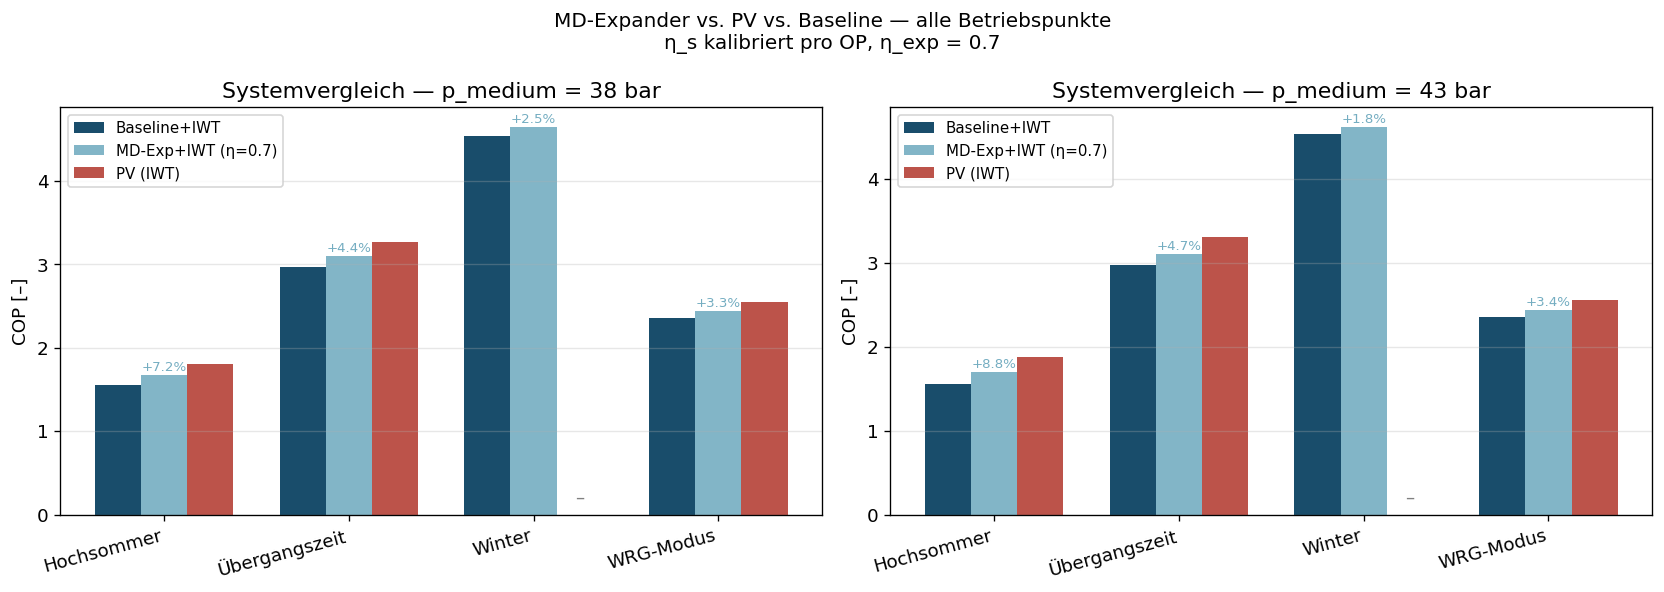

✓ Saved: output/system_comparison_all_ops.png


In [59]:
# =============================================================================
# 4. Fairer Vergleich: Baseline / MD-Exp+IWT / PV — alle Betriebspunkte
# =============================================================================
from copy import deepcopy

def make_pv_op(op_pv, p_med):
    # Clone PV OP and set given p_medium.
    o = deepcopy(op_pv)
    o.p_medium = p_med
    o.p_medium_pv = p_med
    return o

# Compare at two pressure levels: 38 bar (TK-constraint) and 43 bar (BITZER PV)
compare_pressures = [38.0, 43.0]

all_rows = []

for p_med in compare_pressures:
    for label, op_base, op_pv_src in zip(OP_LABELS, BASELINE_OPS, PV_OPS):
        eta_s = ETA_S_CAL[label]

        # Modified OP at chosen p_medium
        op_bl = deepcopy(op_base)
        op_bl.p_medium = p_med

        # 1. Baseline + IWT
        cop_bl, W_bl, _ = run_model(CO2BoosterFlashgasIWT, op_bl, eta_s=eta_s)

        # 2. MD-Exp + IWT (after_exp — standard)
        cop_md, W_md, _ = run_model(CO2BoosterFlashgasIWT, op_bl, eta_s=eta_s,
                                      eta_exp=ETA_EXP, fg="expander")

        # 3. PV — feasibility: 30 Hz minimum speed constraint
        # Reference calibration point: Übergangsjahreszeit PV at exactly 30 Hz
        # minimum → 187 kg/h at p_med=43 bar, T_suction = T_sat(43 bar) + 10 K.
        # V_dot_min_30Hz is derived from this reference point.
        if op_pv_src is not None:
            T_suct_ref = PSI("T", "Q", 1, "P", 43e5, "CO2") - 273.15 + 10.0  # 18.2°C
            rho_ref    = PSI("D", "T", 273.15 + T_suct_ref, "P", 43e5, "CO2")
            V_dot_min  = (187.0 / 3600.0) / rho_ref  # m³/s at 30 Hz (calibrated)

            T_suct_op = PSI("T", "Q", 1, "P", p_med * 1e5, "CO2") - 273.15 + 10.0
            rho_op    = PSI("D", "T", 273.15 + T_suct_op, "P", p_med * 1e5, "CO2")
            m_fg_op   = op_base.m_flashgas or 0.0
            V_dot_op  = (m_fg_op / 3600.0) / rho_op
            n_hz      = (V_dot_op / V_dot_min) * 30.0  # required PV speed [Hz]

            if n_hz < 30.0:
                cop_pv, W_pv = float("nan"), float("nan")
                pv_note = (f"⚠ PV < 30 Hz ({n_hz:.0f} Hz benötigt,"
                           f" m_fg={m_fg_op:.0f} kg/h)")
            else:
                op_pv = make_pv_op(op_pv_src, p_med)
                cop_pv, W_pv, _ = run_model(CO2BoosterParallel, op_pv, eta_s=eta_s)
                pv_note = f"n_PV ≈ {n_hz:.0f} Hz"
        else:
            cop_pv, W_pv = float("nan"), float("nan")
            pv_note = "kein PV-OP (m_fg zu gering für 30 Hz)"

        all_rows.append({
            "p_med [bar]": p_med,
            "Betriebspunkt": label,
            "η_s": eta_s,
            "COP_BL": cop_bl,
            "COP_MD": cop_md,
            "COP_PV": cop_pv,
            "ΔCOP_MD [%]": (cop_md / cop_bl - 1) * 100 if cop_bl > 0 else np.nan,
            "ΔCOP_PV [%]": (cop_pv / cop_bl - 1) * 100 if (cop_bl > 0 and not np.isnan(cop_pv)) else np.nan,
            "W_BL [kW]": W_bl,
            "W_MD [kW]": W_md,
            "W_PV [kW]": W_pv,
            "PV Hinweis": pv_note,
        })

df_comp = pd.DataFrame(all_rows)

# Print table
for p_med in compare_pressures:
    sub = df_comp[df_comp["p_med [bar]"] == p_med]
    print(f"\n{'='*90}")
    print(f"  p_medium = {p_med:.0f} bar")
    print(f"{'='*90}")
    print(f"  {'Betriebspunkt':20s}  {'η_s':>6s}  {'COP BL':>8s}  {'COP MD':>8s}  "
          f"{'COP PV':>8s}  {'ΔMD/BL':>8s}  {'ΔPV/BL':>8s}  Hinweis")
    print(f"  {'-'*88}")
    for _, r in sub.iterrows():
        pv_str = f"{r['COP_PV']:.4f}" if not np.isnan(r["COP_PV"]) else "–"
        dpv_str = f"{r['ΔCOP_PV [%]']:+.1f}%" if not np.isnan(r["ΔCOP_PV [%]"]) else "–"
        print(f"  {r['Betriebspunkt']:20s}  {r['η_s']:6.4f}  {r['COP_BL']:8.4f}  "
              f"{r['COP_MD']:8.4f}  {pv_str:>8s}  {r['ΔCOP_MD [%]']:+7.1f}%  "
              f"{dpv_str:>8s}  {r['PV Hinweis']}")

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
for ax_idx, p_med in enumerate(compare_pressures):
    ax = axes[ax_idx]
    sub = df_comp[df_comp["p_med [bar]"] == p_med].reset_index(drop=True)
    x = np.arange(len(sub))
    w = 0.25
    bars_bl = ax.bar(x - w, sub["COP_BL"], w, color=ECALIA_BLUE,   label="Baseline+IWT", alpha=0.9)
    bars_md = ax.bar(x,     sub["COP_MD"], w, color=ECALIA_TEAL,   label=f"MD-Exp+IWT (η={ETA_EXP})", alpha=0.9)
    bars_pv = ax.bar(x + w, sub["COP_PV"], w, color=ECALIA_RED,    label="PV (IWT)", alpha=0.9)

    # Mark infeasible PV bars
    for i, r in sub.iterrows():
        if np.isnan(r["COP_PV"]):
            ax.text(i + w, 0.1, "–", ha="center", va="bottom", color="gray")

    ax.set_xticks(x)
    ax.set_xticklabels(sub["Betriebspunkt"], rotation=15, ha="right")
    ax.set_ylabel("COP [–]")
    ax.set_title(f"Systemvergleich — p_medium = {p_med:.0f} bar")
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

# Annotate Δ on bars
for ax_idx, p_med in enumerate(compare_pressures):
    ax = axes[ax_idx]
    sub = df_comp[df_comp["p_med [bar]"] == p_med].reset_index(drop=True)
    x = np.arange(len(sub))
    for i, r in sub.iterrows():
        y_bl = r["COP_BL"]
        y_md = r["COP_MD"]
        ax.annotate(f"{r['ΔCOP_MD [%]']:+.1f}%",
                    xy=(i, y_md), xytext=(i, y_md + 0.05),
                    ha="center", fontsize=8, color=ECALIA_TEAL)

fig.suptitle(f"MD-Expander vs. PV vs. Baseline — alle Betriebspunkte\n"
             f"η_s kalibriert pro OP, η_exp = {ETA_EXP}", fontsize=12)
fig.tight_layout()
fig.savefig("output/system_comparison_all_ops.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: output/system_comparison_all_ops.png")

## 5. p_medium-Einfluss im CF-Bereich (36–43 bar)

Kälte Fischer hat in der Email angegeben: *„Mitteldruck kann frei gewählt werden,
sollte möglichst zwischen 36 und 43 bar liegen."*

Dieser Abschnitt untersucht, wie COP und ΔCOP innerhalb dieses Fensters von
p_medium abhängen — für beide Topologien (MD-Exp+IWT und PV), beim
Hochsommerfall (transkritisch, schlechtester COP = wichtigster Betriebspunkt).

**Erkenntnis:** Das TK-System zwingt p_medium ≈ 38 bar (T_sat(38 bar) = 3,3 °C für die
Flüssigkeitsleitung). Das COP-Optimum liegt für den NK-only Betrieb höher.

Sweeping p_medium 36→55 bar  (η_s=0.6909, η_exp=0.7)

  Optima innerhalb CF-Bereich (36–43 bar):
  MD-Exp opt @ 43 bar  → COP = 1.6971
  PV     opt @ 43 bar  → COP = 1.8752

  p_med    COP BL    COP MD    COP PV   ΔMD/BL   ΔPV/BL
------------------------------------------------------------
     36    1.5600    1.6577    1.7673    +6.3%   +13.3%
     37    1.5600    1.6651    1.7857    +6.7%   +14.5%
     38    1.5600    1.6718    1.8031    +7.2%   +15.6%
     39    1.5600    1.6780    1.8195    +7.6%   +16.6%
     40    1.5600    1.6836    1.8349    +7.9%   +17.6%
     41    1.5600    1.6886    1.8493    +8.2%   +18.5%
     42    1.5600    1.6931    1.8627    +8.5%   +19.4%
     43    1.5600    1.6971    1.8752    +8.8%   +20.2%


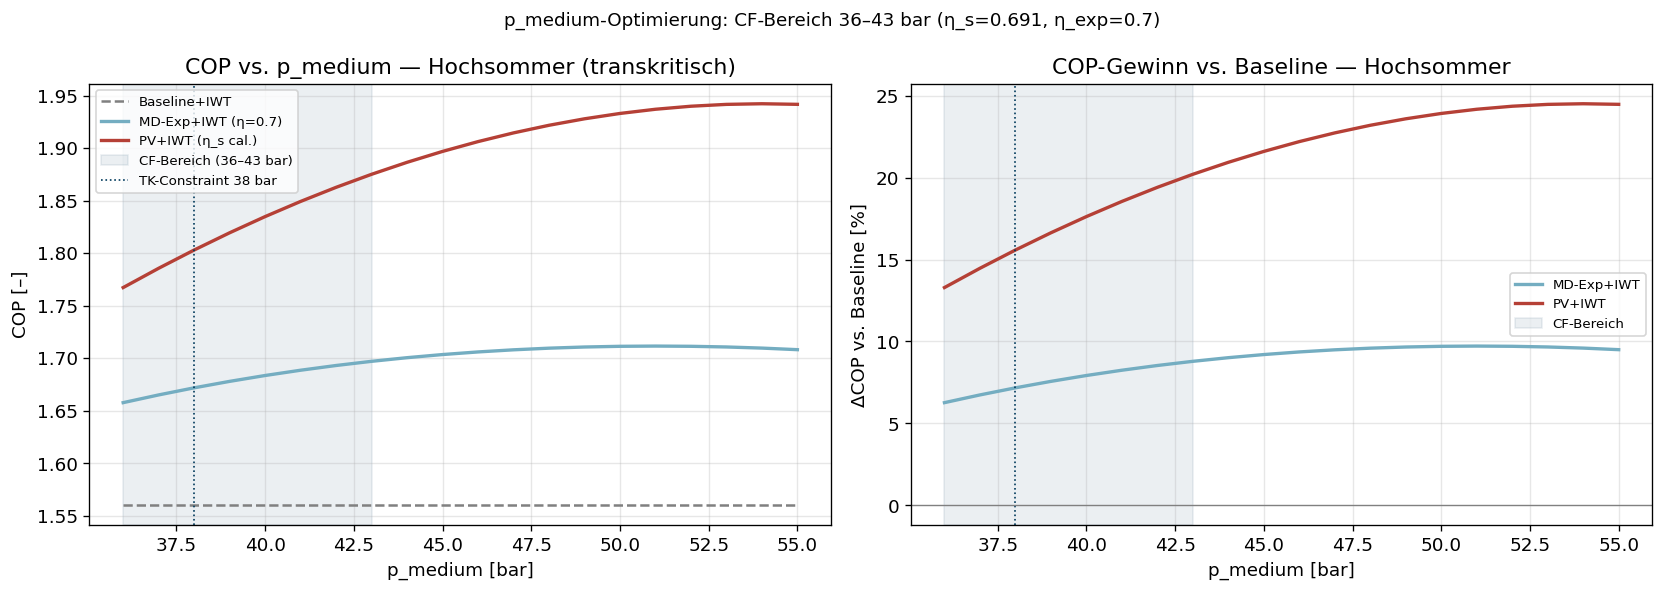

✓ Saved: output/p_medium_sensitivity_CF_range.png


In [60]:
# =============================================================================
# 5. p_medium-Sweep: 36–43 bar (CF-Bereich) + Ausblick bis 55 bar
# =============================================================================
from copy import deepcopy

op_summer  = OP_SUMMER_NO_PV
op_pv_base = OP_SUMMER_WITH_PV
eta_s      = ETA_S_CAL["Hochsommer"]

# Sweep in full CF range + some beyond for context
p_sweep = np.arange(36, 56, 1.0)  # 36..55 bar

sweep_res = {"p_med": [], "cop_bl": [], "cop_md": [], "cop_pv": [],
             "W_bl": [], "W_md": [], "W_exp": [], "W_pv": []}

print(f"Sweeping p_medium 36→55 bar  (η_s={eta_s:.4f}, η_exp={ETA_EXP})")

for p in p_sweep:
    op_b = deepcopy(op_summer); op_b.p_medium = p
    op_p = deepcopy(op_pv_base); op_p.p_medium = p; op_p.p_medium_pv = p

    cop_bl, W_bl, _ = run_model(CO2BoosterFlashgasIWT, op_b, eta_s=eta_s)
    cop_md, W_md, m_md = run_model(CO2BoosterFlashgasIWT, op_b, eta_s=eta_s,
                                    eta_exp=ETA_EXP, fg="expander")
    cop_pv, W_pv, _ = run_model(CO2BoosterParallel, op_p, eta_s=eta_s)

    # Expander power recovery
    W_exp = float("nan")
    if m_md is not None:
        pw = m_md.get_power_breakdown()
        if "fgbv" in pw:
            W_exp = pw["fgbv"]["P_kW"]  # negative = recovery

    sweep_res["p_med"].append(p)
    sweep_res["cop_bl"].append(cop_bl)
    sweep_res["cop_md"].append(cop_md)
    sweep_res["cop_pv"].append(cop_pv)
    sweep_res["W_bl"].append(W_bl)
    sweep_res["W_md"].append(W_md)
    sweep_res["W_exp"].append(W_exp)
    sweep_res["W_pv"].append(W_pv)

df_sweep = pd.DataFrame(sweep_res)
df_cf = df_sweep[df_sweep["p_med"] <= 43]

# Optimal within CF range
cop_md_arr = np.array(df_cf["cop_md"])
cop_pv_arr = np.array(df_cf["cop_pv"])
valid_md = ~np.isnan(cop_md_arr)
valid_pv = ~np.isnan(cop_pv_arr)
p_opt_md_cf = df_cf["p_med"].iloc[np.nanargmax(cop_md_arr)] if valid_md.any() else np.nan
p_opt_pv_cf = df_cf["p_med"].iloc[np.nanargmax(cop_pv_arr)] if valid_pv.any() else np.nan

print(f"\n  Optima innerhalb CF-Bereich (36–43 bar):")
print(f"  MD-Exp opt @ {p_opt_md_cf:.0f} bar  → COP = {df_cf[df_cf['p_med']==p_opt_md_cf]['cop_md'].values[0]:.4f}")
if not np.isnan(p_opt_pv_cf):
    print(f"  PV     opt @ {p_opt_pv_cf:.0f} bar  → COP = {df_cf[df_cf['p_med']==p_opt_pv_cf]['cop_pv'].values[0]:.4f}")

# Print table for CF range
print(f"\n{'p_med':>7s} {'COP BL':>9s} {'COP MD':>9s} {'COP PV':>9s} "
      f"{'ΔMD/BL':>8s} {'ΔPV/BL':>8s}")
print("-"*60)
cop_bl_38 = df_sweep[df_sweep["p_med"] == 38]["cop_bl"].values[0]
for _, r in df_cf.iterrows():
    pv_s = f"{r['cop_pv']:.4f}" if not np.isnan(r["cop_pv"]) else "–"
    dpv  = f"{(r['cop_pv']/r['cop_bl']-1)*100:+.1f}%" if not np.isnan(r["cop_pv"]) else "–"
    print(f"{r['p_med']:7.0f} {r['cop_bl']:9.4f} {r['cop_md']:9.4f} {pv_s:>9s} "
          f"{(r['cop_md']/r['cop_bl']-1)*100:+7.1f}% {dpv:>8s}")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: COP curves over full range
cop_bl_arr = np.array(df_sweep["cop_bl"])
ax1.plot(df_sweep["p_med"], cop_bl_arr,           color="gray",        lw=1.5, ls="--", label="Baseline+IWT")
ax1.plot(df_sweep["p_med"], df_sweep["cop_md"],   color=ECALIA_TEAL,   lw=2,   label=f"MD-Exp+IWT (η={ETA_EXP})")
ax1.plot(df_sweep["p_med"], df_sweep["cop_pv"],   color=ECALIA_RED,    lw=2,   label="PV+IWT (η_s cal.)")
ax1.axvspan(36, 43, alpha=0.08, color=ECALIA_BLUE, label="CF-Bereich (36–43 bar)")
ax1.axvline(38, color=ECALIA_BLUE, lw=1, ls=":", label="TK-Constraint 38 bar")
ax1.set_xlabel("p_medium [bar]")
ax1.set_ylabel("COP [–]")
ax1.set_title("COP vs. p_medium — Hochsommer (transkritisch)")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Right: ΔCOP vs baseline
for lbl, col, key in [("MD-Exp+IWT", ECALIA_TEAL, "cop_md"), ("PV+IWT", ECALIA_RED, "cop_pv")]:
    delta = (np.array(df_sweep[key]) - cop_bl_arr) / cop_bl_arr * 100
    ax2.plot(df_sweep["p_med"], delta, color=col, lw=2, label=lbl)
ax2.axvspan(36, 43, alpha=0.08, color=ECALIA_BLUE, label="CF-Bereich")
ax2.axvline(38, color=ECALIA_BLUE, lw=1, ls=":")
ax2.axhline(0,  color="gray", lw=0.8)
ax2.set_xlabel("p_medium [bar]")
ax2.set_ylabel("ΔCOP vs. Baseline [%]")
ax2.set_title("COP-Gewinn vs. Baseline — Hochsommer")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig.suptitle(f"p_medium-Optimierung: CF-Bereich 36–43 bar (η_s={eta_s:.3f}, η_exp={ETA_EXP})", fontsize=11)
fig.tight_layout()
fig.savefig("output/p_medium_sensitivity_CF_range.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: output/p_medium_sensitivity_CF_range.png")

## 6. MD-Expander Auslegungskriterien (für Kälte Fischer)

Kälte Fischer fragt konkret nach:
- **Rückgewinnungsgrad** (η_exp)
- **Flüssigkeitsanteil** am Austritt (→ Druckverhältnis, Volumenverhältnis)
- **Regelbereich** (→ Massenstrom-Variation über OPs)
- **Optimale Druckdifferenz** (p_medium − p_evap)

Diese werden hier aus den kalibrierten Modellen direkt extrahiert,
inklusive der **η_exp-Schwelle**: Welchen Mindest-Wirkungsgrad muss der Expander
erreichen, damit er den PV übertrifft?

MD-Expander Auslegungskriterien — alle Betriebspunkte (p_med = 38 bar)

  Hochsommer
    p_evap [bar]                        26.49
    p_med [bar]                         38.0
    π_MD = p_med/p_evap                 1.435
    v_r (isentrop)                      1.421
    T_sat @ p_med [°C]                  3.3
    w_s [kJ/kg]                         12.59
    P_exp @ η=0.70 [kW]                 2.77
    x_out @ η=0.70 [–]                  0.941
    m_fg [kg/h]                         1130
    η_exp → PV                          n/a

  Übergangszeit
    p_evap [bar]                        26.49
    p_med [bar]                         38.0
    π_MD = p_med/p_evap                 1.435
    v_r (isentrop)                      1.421
    T_sat @ p_med [°C]                  3.3
    w_s [kJ/kg]                         12.59
    P_exp @ η=0.70 [kW]                 1.18
    x_out @ η=0.70 [–]                  0.941
    m_fg [kg/h]                         480
    η_exp → PV                       

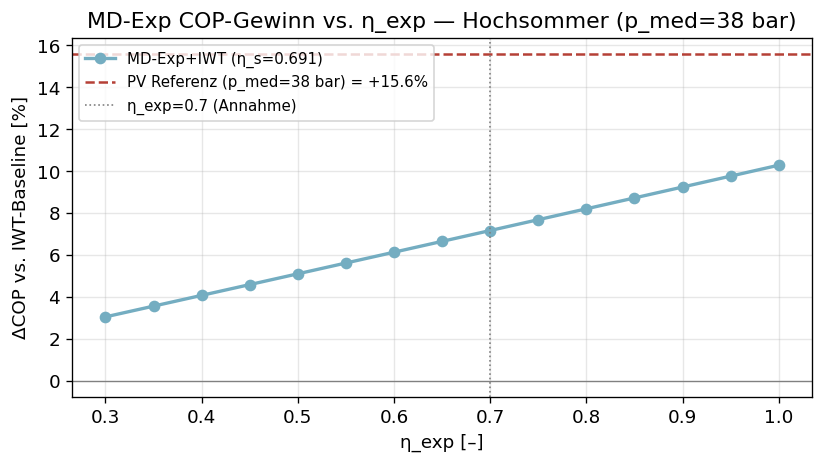

✓ Saved: output/eta_exp_sensitivity.png


In [61]:
# =============================================================================
# 6. MD-Expander Auslegungskriterien — Tabelle für CF
# =============================================================================
from CoolProp.CoolProp import PropsSI as PSI

print("="*85)
print("MD-Expander Auslegungskriterien — alle Betriebspunkte (p_med = 38 bar)")
print("="*85)

design_rows = []
for label, op_base, op_pv_src in zip(OP_LABELS, BASELINE_OPS, PV_OPS):
    eta_s = ETA_S_CAL[label]

    p_evap  = PSI("P", "Q", 1, "T", 273.15 + op_base.T_evap, "CO2") / 1e5  # bar
    p_med   = op_base.p_medium  # 38 bar
    T_sat   = PSI("T", "Q", 1, "P", p_med * 1e5, "CO2") - 273.15          # °C

    # Isentropic specific work (flash gas side, saturated vapor → p_evap)
    h_in  = PSI("H", "Q", 1, "P", p_med  * 1e5, "CO2") / 1e3  # kJ/kg
    s_in  = PSI("S", "Q", 1, "P", p_med  * 1e5, "CO2")
    h_out_s = PSI("H", "S", s_in, "P", p_evap * 1e5, "CO2") / 1e3
    w_s   = h_in - h_out_s   # kJ/kg, isentropic specific work (positive = recovered)

    # Volumetric ratio (isentropic)
    v_in    = 1 / PSI("D", "Q", 1, "P", p_med  * 1e5, "CO2")
    v_out_s = 1 / PSI("D", "S", s_in, "P", p_evap * 1e5, "CO2")
    v_r     = v_out_s / v_in

    # Pressure ratio
    pi_md = p_med / p_evap

    # Expander power (at η_exp = ETA_EXP)
    m_fg_kg_s = (op_base.m_flashgas or 0) / 3600  # kg/s
    P_exp = m_fg_kg_s * w_s * ETA_EXP  # kW

    # Outlet quality / dryness at η=ETA_EXP
    h_out_real = h_in - w_s * ETA_EXP
    x_out = PSI("Q", "H", h_out_real * 1e3, "P", p_evap * 1e5, "CO2")

    # η_exp needed to match PV performance (if PV available)
    eta_threshold = None
    if op_pv_src is not None:
        cop_bl, _, _ = run_model(CO2BoosterFlashgasIWT,
                                  deepcopy(op_base), eta_s=eta_s)
        op_pv_38 = deepcopy(op_pv_src)
        op_pv_38.p_medium = p_med
        op_pv_38.p_medium_pv = p_med
        cop_pv, _, _ = run_model(CO2BoosterParallel, op_pv_38, eta_s=eta_s)
        if not np.isnan(cop_pv):
            def gap(eta):
                cop_md, _, _ = run_model(CO2BoosterFlashgasIWT,
                                          deepcopy(op_base), eta_s=eta_s,
                                          eta_exp=eta, fg="expander")
                return cop_md - cop_pv
            try:
                eta_threshold = brentq(gap, 0.50, 1.00, xtol=1e-3)
            except Exception:
                eta_threshold = None

    row = {
        "Betriebspunkt":        label,
        "p_evap [bar]":         round(p_evap, 2),
        "p_med [bar]":          p_med,
        "π_MD = p_med/p_evap":  round(pi_md, 3),
        "v_r (isentrop)":       round(v_r, 3),
        "T_sat @ p_med [°C]":   round(T_sat, 1),
        "w_s [kJ/kg]":          round(w_s, 2),
        "P_exp @ η=0.70 [kW]":  round(P_exp, 2),
        "x_out @ η=0.70 [–]":   round(x_out, 3),
        "m_fg [kg/h]":          op_base.m_flashgas,
        "η_exp → PV":           f"{eta_threshold:.2f}" if eta_threshold else "n/a",
    }
    design_rows.append(row)
    print(f"\n  {label}")
    for k, v in row.items():
        if k != "Betriebspunkt":
            print(f"    {k:35s} {v}")

df_design = pd.DataFrame(design_rows)
print(f"\n\n  Zusammenfassung:")
print(df_design[["Betriebspunkt", "π_MD = p_med/p_evap", "v_r (isentrop)",
                  "P_exp @ η=0.70 [kW]", "x_out @ η=0.70 [–]",
                  "m_fg [kg/h]", "η_exp → PV"]].to_string(index=False))

# --- Plot: η_exp sensitivity for Hochsommer ---
op_s = OP_SUMMER_NO_PV
eta_s_s = ETA_S_CAL["Hochsommer"]
op_pv_38 = deepcopy(OP_SUMMER_WITH_PV)
op_pv_38.p_medium = 38; op_pv_38.p_medium_pv = 38
cop_bl_s, _, _ = run_model(CO2BoosterFlashgasIWT, op_s, eta_s=eta_s_s)
cop_pv_38, _, _ = run_model(CO2BoosterParallel, op_pv_38, eta_s=eta_s_s)

eta_vals = np.linspace(0.30, 1.00, 15)
delta_md = []
for eta in eta_vals:
    cop, _, _ = run_model(CO2BoosterFlashgasIWT, op_s, eta_s=eta_s_s,
                           eta_exp=eta, fg="expander")
    delta_md.append((cop - cop_bl_s) / cop_bl_s * 100 if not np.isnan(cop) else np.nan)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eta_vals, delta_md, "o-", color=ECALIA_TEAL, lw=2, label=f"MD-Exp+IWT (η_s={eta_s_s:.3f})")
if not np.isnan(cop_pv_38):
    dpv = (cop_pv_38 - cop_bl_s) / cop_bl_s * 100
    ax.axhline(dpv, color=ECALIA_RED, ls="--", lw=1.5, label=f"PV Referenz (p_med=38 bar) = {dpv:+.1f}%")
ax.axvline(ETA_EXP, color="gray", ls=":", lw=1, label=f"η_exp={ETA_EXP} (Annahme)")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("η_exp [–]")
ax.set_ylabel("ΔCOP vs. IWT-Baseline [%]")
ax.set_title(f"MD-Exp COP-Gewinn vs. η_exp — Hochsommer (p_med=38 bar)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig("output/eta_exp_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: output/eta_exp_sensitivity.png")

## 7. Jährliche Energieanalyse & Einsparpotenzial

Kombination der Einzelpunkt-Ergebnisse (kalibrierte η_s, η_exp = 0.70)
mit den saisonalen Betriebsstunden zu einer Jahresbilanz:

| Betriebsmodus | h/a |
|---|---|
| Hochsommer | 800 |
| Übergangszeit | 3.960 |
| Winter | 2.000 |
| WRG-Modus | 2.000 |
| **Gesamt** | **8.760** |

PV ist im Winter **nicht einsetzbar** (0 kWh Einsparung), weil der
Flashgas-Volumenstrom zu gering ist für die Mindestdrehzahl (30 Hz) des
PV-Verdichters — der MD-Expander, der kein Mindestdrehzahl-Limit hat, ist
hier strukturell im Vorteil.

Betriebspunkt  h/a  E_BL [kWh/a]  E_MD [kWh/a]  E_PV [kWh/a]  ΔE_MD [kWh/a]  ΔE_PV [kWh/a]  Δ€_MD [€/a]  Δ€_PV [€/a]
   Hochsommer  800         50615         47229         43570           3386           7045          745         1550
Übergangszeit 3960        131467        125969        119309           5497          12158         1209         2675
       Winter 2000         43568         42526         43568           1042              0          229            0
    WRG-Modus 2000         83220         80582         77708           2638           5513          580         1213

  GESAMT Baseline:           308,870 kWh/a
  MD-Exp Einsparung:         12,563 kWh/a =  2,763 €/a (4.1% von Baseline)
  PV Einsparung:             24,716 kWh/a =  5,438 €/a (8.0% von Baseline)
  MD-Exp erreicht 51% der PV-Einsparung (inkl. PV-Winterausfall)


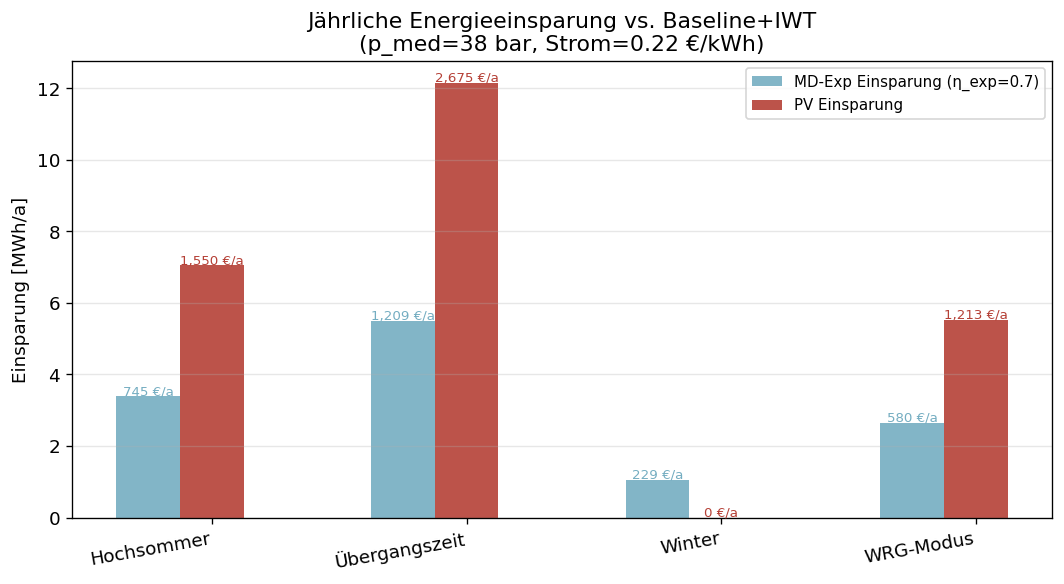

✓ Saved: output/annual_energy_savings.png
✓ CSV: output/annual_energy_summary.csv


In [62]:
# =============================================================================
# 7. Jährliche Energieanalyse
# =============================================================================
ELECTRICITY_PRICE = 0.22  # EUR/kWh

energy_rows = []
for label, op_base, op_pv_src in zip(OP_LABELS, BASELINE_OPS, PV_OPS):
    eta_s = ETA_S_CAL[label]
    hours = HOURS_PER_YEAR[label]

    # Baseline+IWT
    cop_bl, W_bl, _ = run_model(CO2BoosterFlashgasIWT, op_base, eta_s=eta_s)
    # MD-Exp+IWT @ 38 bar
    cop_md, W_md, _ = run_model(CO2BoosterFlashgasIWT, op_base, eta_s=eta_s,
                                  eta_exp=ETA_EXP, fg="expander")
    # PV @ 38 bar (fair) — check 30 Hz minimum speed constraint
    cop_pv = float("nan")
    if op_pv_src is not None:
        # Same 30 Hz calibration as Ch. 4
        T_suct_ref = PSI("T", "Q", 1, "P", 43e5, "CO2") - 273.15 + 10.0
        rho_ref    = PSI("D", "T", 273.15 + T_suct_ref, "P", 43e5, "CO2")
        V_dot_min  = (187.0 / 3600.0) / rho_ref
        T_suct_38  = PSI("T", "Q", 1, "P", 38e5,  "CO2") - 273.15 + 10.0
        rho_38     = PSI("D", "T", 273.15 + T_suct_38,  "P", 38e5,  "CO2")
        m_fg_op    = op_base.m_flashgas or 0.0
        V_dot_op   = (m_fg_op / 3600.0) / rho_38
        n_hz       = (V_dot_op / V_dot_min) * 30.0
        op_pv_38 = deepcopy(op_pv_src); op_pv_38.p_medium = 38; op_pv_38.p_medium_pv = 38
        if n_hz >= 30.0:
            cop_pv, _, _ = run_model(CO2BoosterParallel, op_pv_38, eta_s=eta_s)

    # Annual energy consumption [kWh/a]
    # E = W_net [kW] × hours [h/a]
    E_bl = W_bl * hours
    E_md = W_md * hours

    # Need W_pv for energy calc
    if not np.isnan(cop_pv) and op_pv_src is not None:
        _, W_pv_val, _ = run_model(CO2BoosterParallel, op_pv_38, eta_s=eta_s)
        E_pv = W_pv_val * hours
    else:
        E_pv = E_bl

    energy_rows.append({
        "Betriebspunkt":  label,
        "h/a":            hours,
        "η_s":            eta_s,
        "COP_BL":         cop_bl,
        "COP_MD":         cop_md,
        "COP_PV":         cop_pv if not np.isnan(cop_pv) else "–",
        "E_BL [kWh/a]":  round(E_bl),
        "E_MD [kWh/a]":  round(E_md),
        "E_PV [kWh/a]":  round(E_pv),
        "ΔE_MD [kWh/a]": round(E_bl - E_md),
        "ΔE_PV [kWh/a]": round(E_bl - E_pv),
        "Δ€_MD [€/a]":   round((E_bl - E_md) * ELECTRICITY_PRICE),
        "Δ€_PV [€/a]":   round((E_bl - E_pv) * ELECTRICITY_PRICE),
    })

df_energy = pd.DataFrame(energy_rows)

# Totals
total_E_bl  = df_energy["E_BL [kWh/a]"].sum()
total_dE_md = df_energy["ΔE_MD [kWh/a]"].sum()
total_dE_pv = df_energy["ΔE_PV [kWh/a]"].sum()
total_dc_md = df_energy["Δ€_MD [€/a]"].sum()
total_dc_pv = df_energy["Δ€_PV [€/a]"].sum()

print(df_energy[["Betriebspunkt","h/a","E_BL [kWh/a]","E_MD [kWh/a]",
                  "E_PV [kWh/a]","ΔE_MD [kWh/a]","ΔE_PV [kWh/a]",
                  "Δ€_MD [€/a]","Δ€_PV [€/a]"]].to_string(index=False))
print(f"\n  GESAMT Baseline:        {total_E_bl:>10,.0f} kWh/a")
print(f"  MD-Exp Einsparung:     {total_dE_md:>10,.0f} kWh/a = {total_dc_md:>6,.0f} €/a "
      f"({total_dE_md/total_E_bl*100:.1f}% von Baseline)")
print(f"  PV Einsparung:         {total_dE_pv:>10,.0f} kWh/a = {total_dc_pv:>6,.0f} €/a "
      f"({total_dE_pv/total_E_bl*100:.1f}% von Baseline)")
if total_dc_pv > 0:
    print(f"  MD-Exp erreicht {total_dc_md/total_dc_pv*100:.0f}% der PV-Einsparung (inkl. PV-Winterausfall)")

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(9, 5))
x  = np.arange(len(df_energy))
w  = 0.25
ax.bar(x - w, df_energy["ΔE_MD [kWh/a]"] / 1e3, w, color=ECALIA_TEAL,
       label=f"MD-Exp Einsparung (η_exp={ETA_EXP})", alpha=0.9)
ax.bar(x,     df_energy["ΔE_PV [kWh/a]"] / 1e3,  w, color=ECALIA_RED,
       label="PV Einsparung",  alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(df_energy["Betriebspunkt"], rotation=10, ha="right")
ax.set_ylabel("Einsparung [MWh/a]")
ax.set_title(f"Jährliche Energieeinsparung vs. Baseline+IWT\n(p_med=38 bar, Strom={ELECTRICITY_PRICE} €/kWh)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)

# Annotate savings in €/a
for i, r in df_energy.iterrows():
    ax.text(i - w, r["ΔE_MD [kWh/a]"]/1e3 + 0.05,
            f"{r['Δ€_MD [€/a]']:,.0f} €/a", ha="center", fontsize=8, color=ECALIA_TEAL)
    ax.text(i,     r["ΔE_PV [kWh/a]"]/1e3 + 0.05,
            f"{r['Δ€_PV [€/a]']:,.0f} €/a", ha="center", fontsize=8, color=ECALIA_RED)

fig.tight_layout()
fig.savefig("output/annual_energy_savings.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Saved: output/annual_energy_savings.png")

# CSV export
df_energy.to_csv("output/annual_energy_summary.csv", index=False, float_format="%.3f")
print("✓ CSV: output/annual_energy_summary.csv")